In [4]:
import numpy as np
result1 = np.array([[5, 2], [1, 3]], np.complex128)
result2 = np.array([[1, 0], [2, 0]], np.complex128)
def coupling(matrix_1,matrix_2):                         #  matrix coupling
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result
coupling(result1,result2)                                                    
def multiple_coupling(matrix_collect_1):                #multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

In [5]:
m=0.5#complex(9.1093837*10**(-31))                                                    一实狄拉克函数
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=0.5#(-1*10**(-15))
x_1=1#(1*10**(-15))
location = np.linspace(x_0, x_1, 2)
N=1                                               
y=1
di=np.arange(0,N,dtype=complex)
constant_1=2*m*y/(h1**2)
for i in np.arange(N):
    di[i]=constant_1*(-1)**i
print(di,'di')  
print(f"波矢k为{k},能量为{E}，位置在{location[0]},狄拉克函数前的常数为{y}")              #constant

matrix_collect = np.zeros((N, 2, 2), dtype=complex)
#print(matrix_collect,type(matrix_collect),'matrix_collect') 

for i in np.arange(N):
    s11=di[i]*np.exp((2j)*k*location[i])
    s12=2j*k
    s21=2j*k
    s22=di[i]*np.exp((-2j)*k*location[i])
    if i==len(np.arange(N))-1:
        s12=0
        s22=0
    matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
    matrix_collect[i]=matrix_3
#    print(matrix_3)
#print(matrix_collect)                                                             #matrix_collect
matrix4=matrix_collect[0]
#matrix5=matrix_collect[1]
#print(matrix4,'\n',matrix5)
print(f"耦合矩阵为\n{matrix4}\n反射系数:{abs(matrix4[0][0])**2},透射系数:{abs(matrix4[1][0]**2)},两者之和:{abs(matrix4[0][0])**2+abs(matrix4[1][0]**2)}")         #test                                     #real

[1.+0.j] di
波矢k为(1+0j),能量为(1+0j)，位置在0.5,狄拉克函数前的常数为1
耦合矩阵为
[[0.22852793-0.38441512j 0.        -0.j        ]
 [0.8       -0.4j        0.        -0.j        ]]
反射系数:0.19999999999999998,透射系数:0.8000000000000002,两者之和:1.0000000000000002


In [6]:
a=abs(matrix4[0][0])**2
b=abs(matrix4[1][0])**2
print(a,b,a+b)

0.19999999999999998 0.8000000000000002 1.0000000000000002


In [7]:
m=0.5#complex(9.1093837*10**(-31))                                       #两个实狄拉克函数
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))
location = np.linspace(x_0, x_1, 2)
N=2                                               
y=1
di=np.arange(0,N,dtype=complex)
constant_1=2*m*y/(h1**2)
for i in np.arange(N):
    di[i]=constant_1*(-1)**i                                                #constant
print(di,'di')  
print(f"波矢k为{k},能量为{E},位置在{location},狄拉克函数前的常数为{y}") 

matrix_collect = np.zeros((N, 2, 2), dtype=complex)
for i in np.arange(N):
    s11=di[i]*np.exp((2j)*k*location[i])
    s12=2j*k
    s21=2j*k
    s22=di[i]*np.exp((-2j)*k*location[i])
    if i==len(np.arange(N))-1:
        s12=0
        s22=0
    matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
    matrix_collect[i]=matrix_3
#print(matrix_collect)
def multiple_coupling(matrix_collect_1):                             #multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2
matrix_6 = multiple_coupling(matrix_collect)
print(f"耦合矩阵为\n{matrix_6}\n反射系数:{abs(matrix_6[0][0])**2},透射系数:{abs(matrix_6[1][0]**2)}")
print(f"两者之和:{abs(matrix_6[0][0])**2+abs(matrix_6[1][0]**2)}")

[ 1.+0.j -1.+0.j] di
波矢k为(1+0j),能量为(1+0j),位置在[-0.5  0.5],狄拉克函数前的常数为1
耦合矩阵为
[[-0.65515433+0.20073529j  0.        +0.j        ]
 [ 0.71828689+0.1205906j   0.        +0.j        ]]
反射系数:0.46952184800403646,透射系数:0.530478151995964
两者之和:1.0000000000000004


In [8]:
m=0.5#complex(9.1093837*10**(-31))                                       #n个实狄拉克函数
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))
N=1000
location = np.linspace(x_0, x_1, N)                                             
y=1
di=np.arange(0,N,dtype=complex)
constant_1=2*m*y/(h1**2)
for i in np.arange(N):
    di[i]=constant_1*(-1)**i                                                #constant
#print(di,'di')  
print(f"波矢k为{k},能量为{E},狄拉克函数前的常数为{y}") 

matrix_collect = np.zeros((N, 2, 2), dtype=complex)
for i in np.arange(N):
    s11=di[i]*np.exp((2j)*k*location[i])
    s12=2j*k
    s21=2j*k
    s22=di[i]*np.exp((-2j)*k*location[i])
    if i==len(np.arange(N))-1:
        s12=0
        s22=0
    matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
    matrix_collect[i]=matrix_3
#print(matrix_collect)
def multiple_coupling(matrix_collect_1):                             #multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2
matrix_6 = multiple_coupling(matrix_collect)
print(f"耦合矩阵为\n{matrix_6}\n反射系数:{abs(matrix_6[0][0])**2},透射系数:{abs(matrix_6[1][0]**2)}")
print(f"两者之和:{abs(matrix_6[0][0])**2+abs(matrix_6[1][0]**2)}")

波矢k为(1+0j),能量为(1+0j),狄拉克函数前的常数为1
耦合矩阵为
[[-0.39154758+0.12249973j  0.        +0.j        ]
 [ 0.90025577+0.14568411j  0.        +0.j        ]]
反射系数:0.16831569007304184,透射系数:0.8316843099270701
两者之和:1.000000000000112


In [29]:
m=0.5#complex(9.1093837*10**(-31))                                       #N个虚数狄拉克函数
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))
N=1000
location = np.linspace(x_0, x_1, N)                                             
y=1j
di=np.zeros((N), dtype=complex)
constant_1=2*m*y/(h1**2)
for i in np.arange(N):
    di[i]=constant_1*(-1)**i                                                #constant
#print(di,'di')  
print(f"波矢k为{k},能量为{E},狄拉克函数前的常数为{y}") 

matrix_collect = np.zeros((N, 2, 2), dtype=complex)
for i in np.arange(N):
    s11=di[i]*np.exp((2j)*k*location[i])
    s12=2j*k
    s21=2j*k
    s22=di[i]*np.exp((-2j)*k*location[i])
    if i==len(np.arange(N))-1:
        s12=0
        s22=0
    matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
    matrix_collect[i]=matrix_3
matrix_6 = multiple_coupling(matrix_collect)
print(f"耦合矩阵为\n{matrix_6}\n反射系数:{abs(matrix_6[0][0])**2},透射系数:{abs(matrix_6[1][0]**2)}")
print(f"两者之和:{abs(matrix_6[0][0])**2+abs(matrix_6[1][0]**2)}")

波矢k为(1+0j),能量为(1+0j),狄拉克函数前的常数为1j
耦合矩阵为
[[-0.14583302-0.69904841j  0.        +0.j        ]
 [ 1.05885967-0.22089558j  0.        +0.j        ]]
反射系数:0.5099359508254743,透射系数:1.1699786502751164
两者之和:1.6799146011005908


In [32]:
m=0.5#complex(9.1093837*10**(-31))                                      #作图
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))                                             
y=1j
constant_1=2*m*y/(h1**2)                                             #constant

def coupling_matrix_of_N(N):
    location = np.linspace(x_0, x_1, N)
    di=np.zeros((N),dtype=complex)
    for i in np.arange(N):
        di[i]=constant_1*(-1)**i 
    matrix_collect = np.zeros((N, 2, 2), dtype=complex)
    for i in np.arange(N):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(N))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[1][0]**2))
def Reflection_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[0][0]**2))

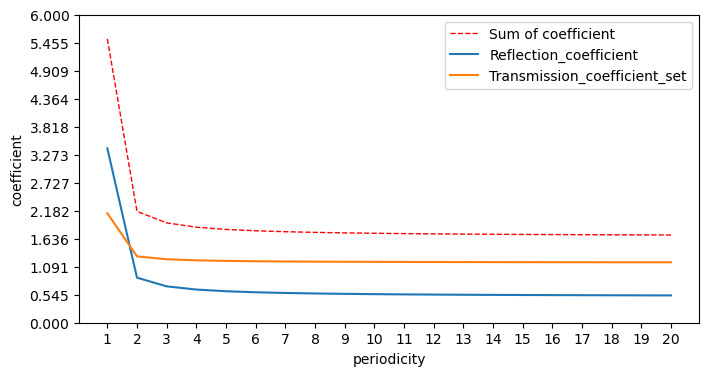

In [33]:
import matplotlib.pyplot as plt                       #作图
import numpy as np
n1=1                                                               
n2=20
Reflection_coefficient_set=np.zeros((n2),dtype=float)
for i in np.arange(n1,n2+1):
    Reflection_coefficient_set[i-1]= Reflection_coefficient_of_N(2*i)
Transmission_coefficient_set=np.zeros((n2),dtype=float)
for i in np.arange(n1,n2+1):
    Transmission_coefficient_set[i-1]= Transmission_coefficient_of_N(2*i)
period_X= np.arange(n1,n2+1,1)
#print(period_X)
x = period_X
y1 = Reflection_coefficient_set
y2 = Transmission_coefficient_set
plt.figure(num=2, figsize=(8, 4))
plt.plot(x, y1+y2, color='red', linewidth='1.0', linestyle='--',label='Sum of coefficient')
plt.plot(x, y1,label='Reflection_coefficient')
plt.plot(x, y2,label='Transmission_coefficient_set')
plt.xlabel('periodicity')
plt.ylabel('coefficient')
new_ticks1 = np.linspace(1, 20, 20)
new_ticks2 = np.linspace(0, 6, 12)
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.legend()
plt.show()

In [13]:
Transmission_coefficient_of_N(1000)

1.1699786502751164

In [14]:
Reflection_coefficient_of_N(1000)

0.5099359508254742